# 08D – Error Analysis

Enterprise notebook for analyzing model errors and identifying patterns behind false positives and false negatives.

## Business Objective
Understand where the bankruptcy prediction model makes mistakes and identify opportunities for improvement.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

In [2]:
DATA_PATH='../data/datasets/american_bankruptcy_cleaned.csv'
MODEL_PATH='../models/production_bankruptcy_model.joblib'

df=pd.read_csv(DATA_PATH)

if 'status_label' in df.columns:
    y=df['status_label'].map({'alive':0,'failed':1})
    X=df.drop(columns=[col for col in ['status_label','company_name'] if col in df.columns])
elif 'target' in df.columns:
    y=df['target']
    X=df.drop(columns=[col for col in ['target','company_name'] if col in df.columns])
else:
    raise ValueError('Target column not found')

_,X_test,_,y_test=train_test_split(
    X,y,test_size=0.2,random_state=42,stratify=y)

model=joblib.load(MODEL_PATH)
y_pred=model.predict(X_test)


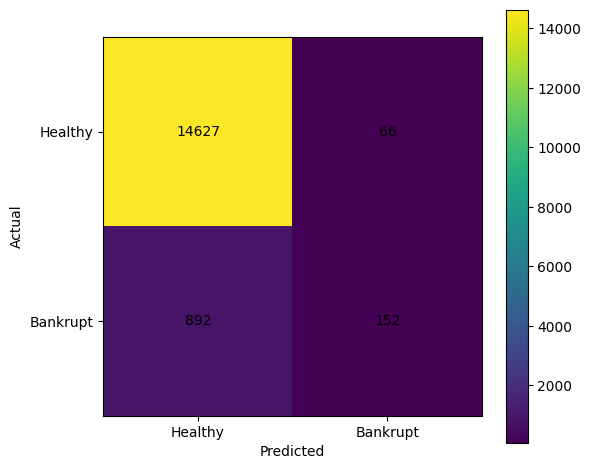

In [3]:
cm=confusion_matrix(y_test,y_pred)

plt.figure(figsize=(6,5))
plt.imshow(cm)
plt.colorbar()
plt.xticks([0,1],['Healthy','Bankrupt'])
plt.yticks([0,1],['Healthy','Bankrupt'])
plt.xlabel('Predicted')
plt.ylabel('Actual')

for i in range(2):
    for j in range(2):
        plt.text(j,i,str(cm[i,j]),ha='center',va='center')

plt.tight_layout()
plt.savefig('confusion_matrix.png',dpi=300)
plt.show()


In [4]:
report=pd.DataFrame(classification_report(y_test,y_pred,output_dict=True)).T
report.to_csv('classification_report.csv')

results=X_test.copy()
results['Actual']=y_test.values
results['Predicted']=y_pred
results['Error_Type']='Correct'
results.loc[(results.Actual==0)&(results.Predicted==1),'Error_Type']='False Positive'
results.loc[(results.Actual==1)&(results.Predicted==0),'Error_Type']='False Negative'

results.to_csv('prediction_error_analysis.csv',index=False)

results['Error_Type'].value_counts()


Error_Type
Correct           14779
False Negative      892
False Positive       66
Name: count, dtype: int64

## Business Interpretation

- **False Positives:** Healthy companies incorrectly flagged as bankrupt. These may lead to unnecessary reviews or rejected applications.
- **False Negatives:** Bankrupt companies predicted as healthy. These are often the most costly errors in credit risk and lending.
- Review patterns in the exported error file to identify recurring characteristics and guide feature engineering or threshold adjustments.

## Deliverables

- `confusion_matrix.png`
- `classification_report.csv`
- `prediction_error_analysis.csv`

This notebook documents model errors and provides a foundation for targeted model improvements.